# 📊 Phân Tích & So Sánh Toàn Diện Các Mô Hình PM2.5
Notebook này phân tích **có hệ thống** hiệu năng của 6 mô hình trên 3 Data Blocks khác nhau, qua 5 góc nhìn trực quan.

| Góc nhìn | Mục đích |
|---|---|
| 1. Heatmap Tổng Hợp | Nhìn 1 phát biết model nào tốt nhất |
| 2. Grouped Bar Chart | So sánh tại từng Horizon cụ thể |
| 3. Radar Chart | Đánh giá sức mạnh tổng thể |
| 4. Box Plot Stability | Đo độ ổn định xuyên Block |
| 5. Line Plot Chi Tiết | Phân tích sâu Bắc/Nam/TB từng Block |

In [12]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from math import pi
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'figure.facecolor': 'white'
})

with open('../benchmark_metrics.json', 'r') as f:
    raw = json.load(f)

block_order = ['block30', 'block7', 'block5']
blocks = [b for b in block_order if b in raw['data']] + [b for b in raw['data'].keys() if b not in block_order]
models = raw['models']
horizons = raw['horizons']
metrics = raw['metrics']
regions = ['north', 'south', 'aggregated']
region_vn = {'north': 'Miền Bắc', 'south': 'Miền Nam', 'aggregated': 'Trung Bình'}
metric_better = {'RMSE': 'lower', 'MAE': 'lower', 'R2': 'higher'}

# Flatten data thành DataFrame để tiện thao tác
rows = []
for block in blocks:
    for region in regions:
        for metric in metrics:
            for model in models:
                vals = raw['data'][block][region][metric][model]
                for i, h in enumerate(horizons):
                    rows.append({
                        'block': block, 'region': region,
                        'metric': metric, 'model': model,
                        'horizon': h, 'value': vals[i]
                    })

df = pd.DataFrame(rows)
print(f'✅ Loaded {len(df)} records | {len(blocks)} blocks | {len(models)} models')
print('Block order:', blocks)
df.head()

✅ Loaded 810 records | 3 blocks | 6 models
Block order: ['block30', 'block7', 'block5']


,block,region,metric,model,horizon,value
0,block30,north,RMSE,XGBoost,T+1,13.75
1,block30,north,RMSE,XGBoost,T+3,17.34
2,block30,north,RMSE,XGBoost,T+6,18.65
3,block30,north,RMSE,XGBoost,T+12,19.99
4,block30,north,RMSE,XGBoost,T+24,22.04


---
## 1️⃣ HEATMAP TỔNG HỢP — Nhìn 1 phát, biết hết
Mỗi ô hiển thị giá trị **Aggregated** (trung bình có trọng số). Trục Y = `Model × Block`, Trục X = `Horizon`.
- 🟢 Xanh = Tốt hơn (MAE/RMSE thấp hoặc R² cao)
- 🔴 Đỏ = Kém hơn

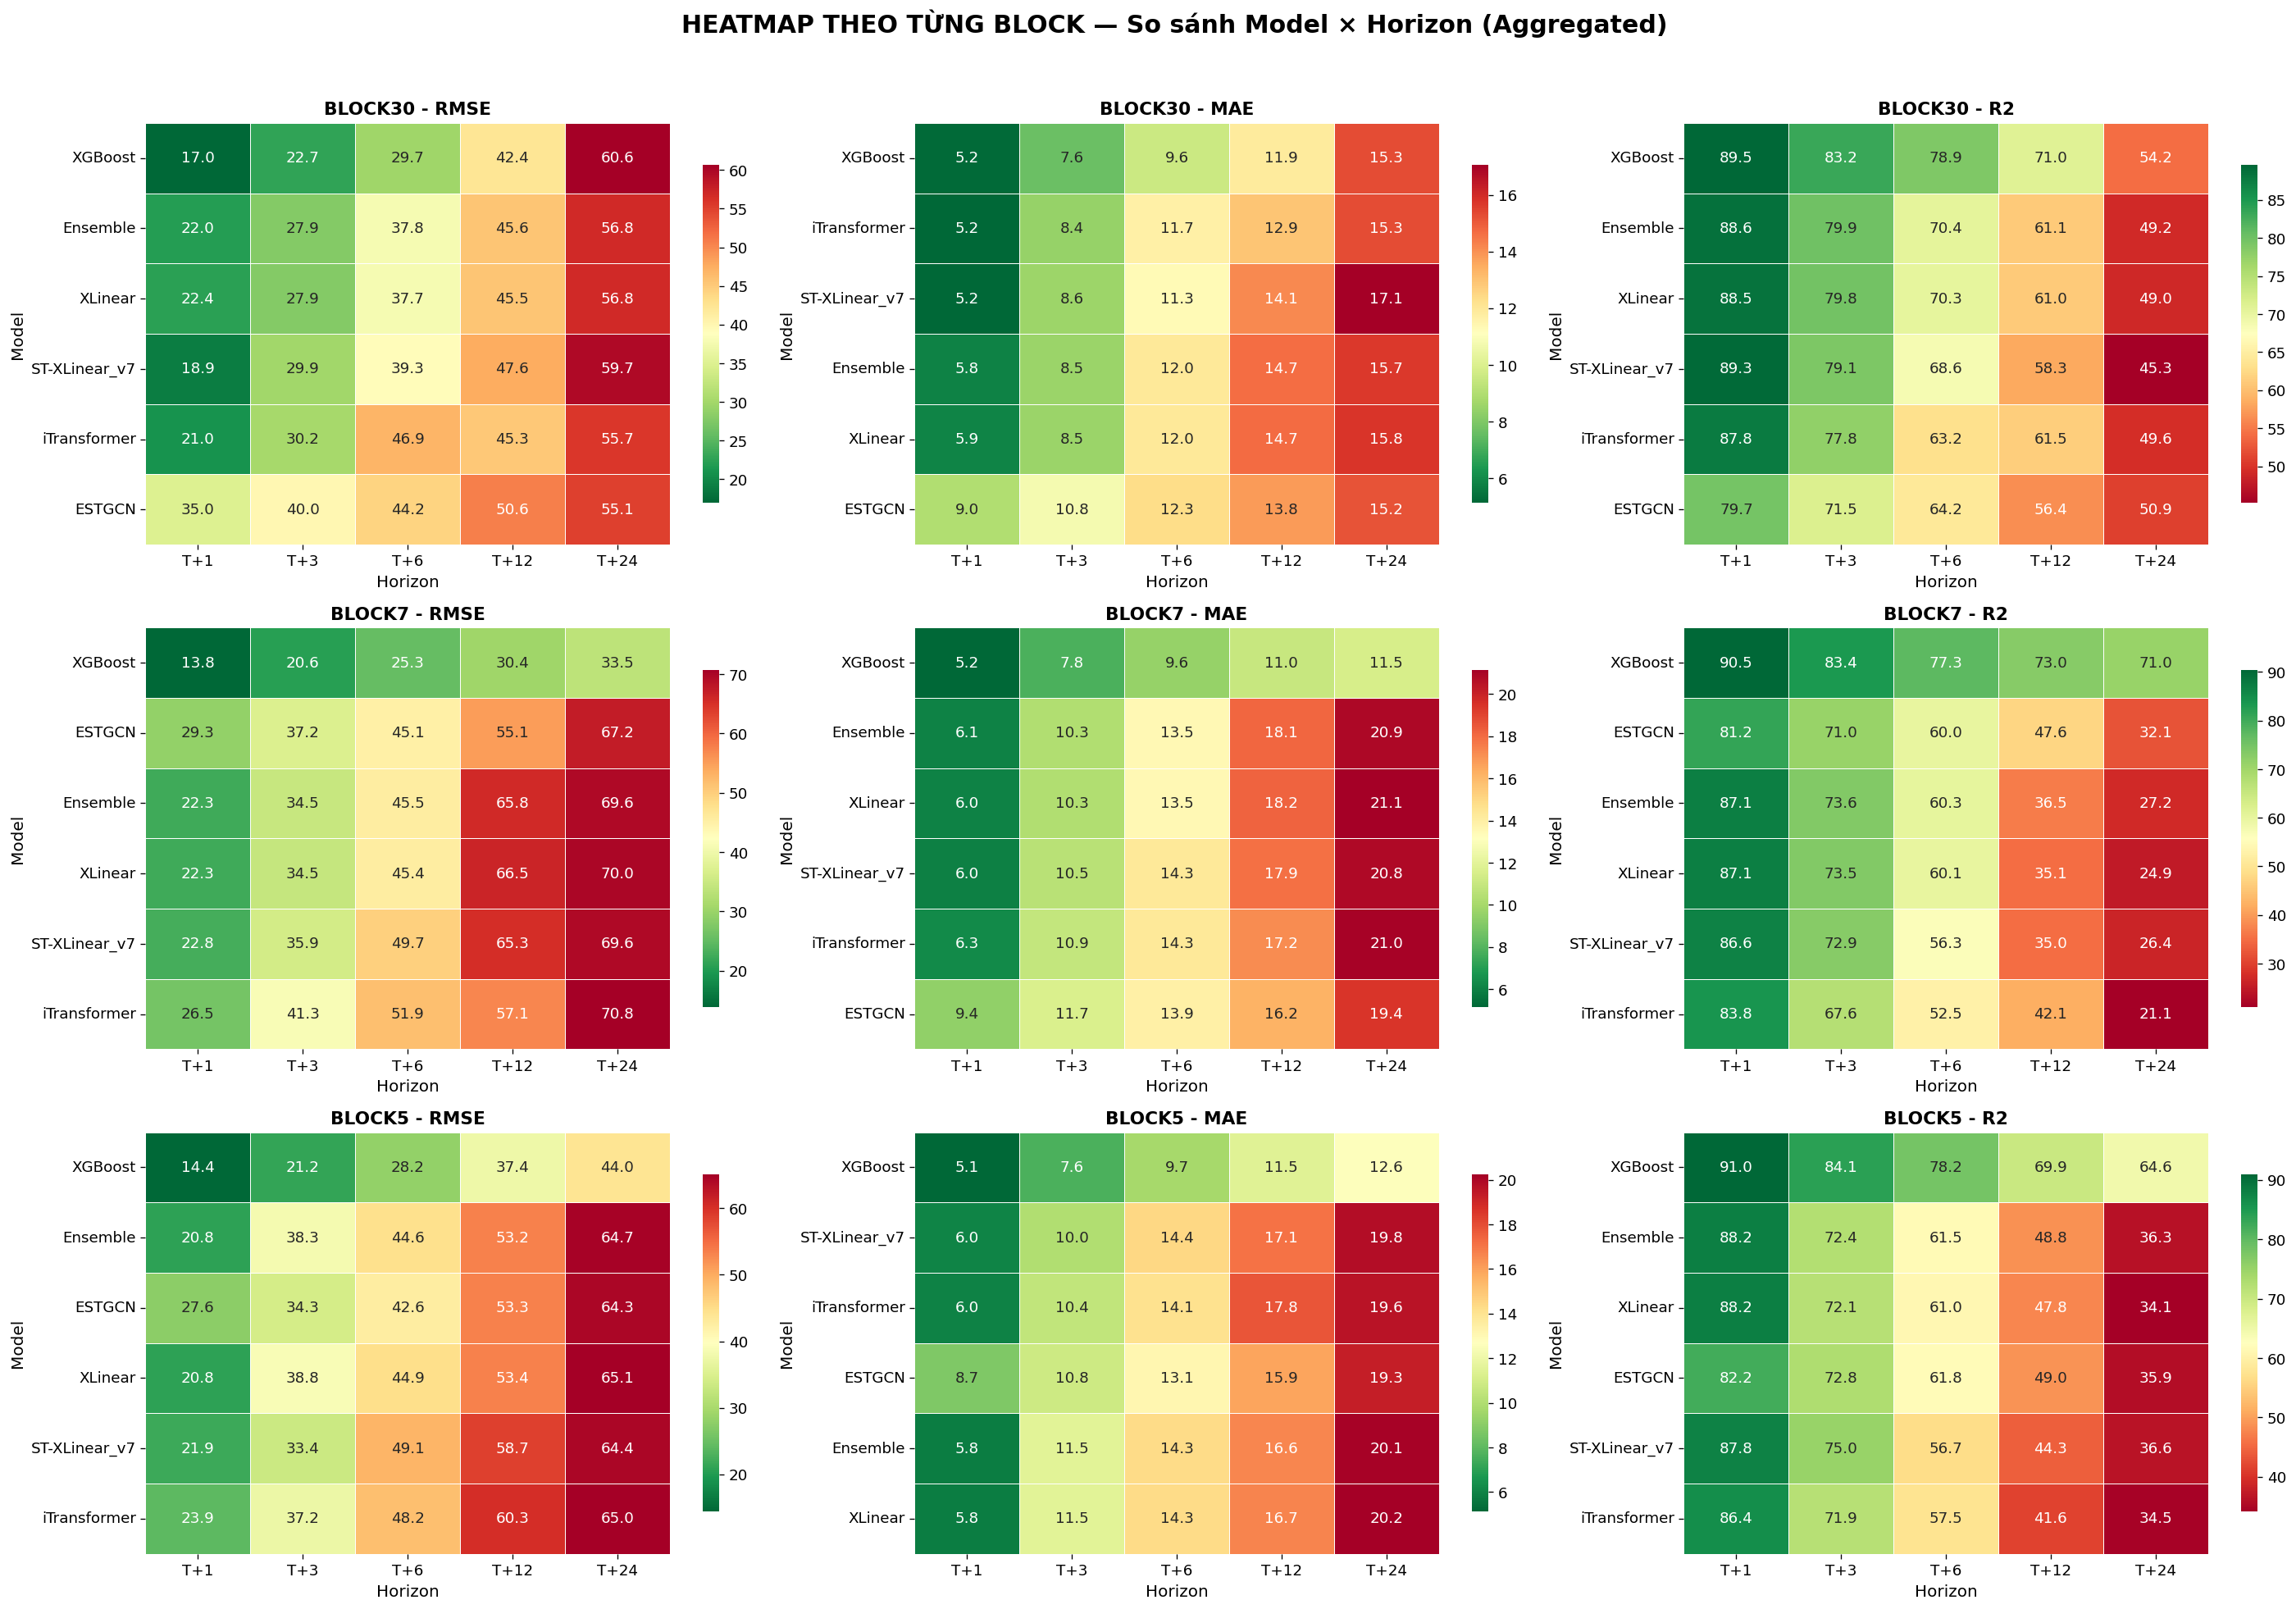

In [18]:
block_order = ['block30', 'block7', 'block5']
fig, axes = plt.subplots(len(block_order), len(metrics), figsize=(24, 16), squeeze=False)

for row, block in enumerate(block_order):
    for col, metric in enumerate(metrics):
        ax = axes[row][col]
        sub = df[
            (df['region'] == 'aggregated') &
            (df['metric'] == metric) &
            (df['block'] == block)
        ]

        pivot = sub.pivot_table(index='model', columns='horizon', values='value')
        pivot = pivot[horizons]  # đảm bảo thứ tự cột

        # Sắp xếp model theo giá trị tốt nhất (trung bình qua horizon)
        ascending = True if metric_better[metric] == 'lower' else False
        pivot['_mean'] = pivot.mean(axis=1)
        pivot = pivot.sort_values('_mean', ascending=ascending).drop(columns='_mean')

        cmap = 'RdYlGn' if metric == 'R2' else 'RdYlGn_r'
        sns.heatmap(
            pivot,
            annot=True,
            fmt='.1f',
            cmap=cmap,
            linewidths=0.5,
            ax=ax,
            cbar_kws={'shrink': 0.8}
        )

        ax.set_title(f'{block.upper()} - {metric}', fontsize=13, fontweight='bold')
        ax.set_ylabel('Model')
        ax.set_xlabel('Horizon')

plt.suptitle(
    'HEATMAP THEO TỪNG BLOCK — So sánh Model × Horizon (Aggregated)',
    fontsize=18,
    fontweight='bold',
    y=1.02
    )
plt.tight_layout()
plt.show()

**📝 Cách đọc Heatmap:**
- Nhìn từ trên xuống dưới theo cột: Model + Block nào có ô xanh nhất → Tốt nhất.
- So sánh ngang (cùng 1 Model): Nếu các ô thay đổi màu ít giữa Block → Model ổn định.
- So sánh dọc (cùng 1 Horizon): Ô xanh nhất ở dưới cùng = Best model cho horizon đó.

---
## 2️⃣ GROUPED BAR CHART — Tại mỗi Horizon, ai thắng?
Với mỗi Horizon, nhóm các thanh Bar cạnh nhau (1 thanh = 1 Model), chia theo Block.

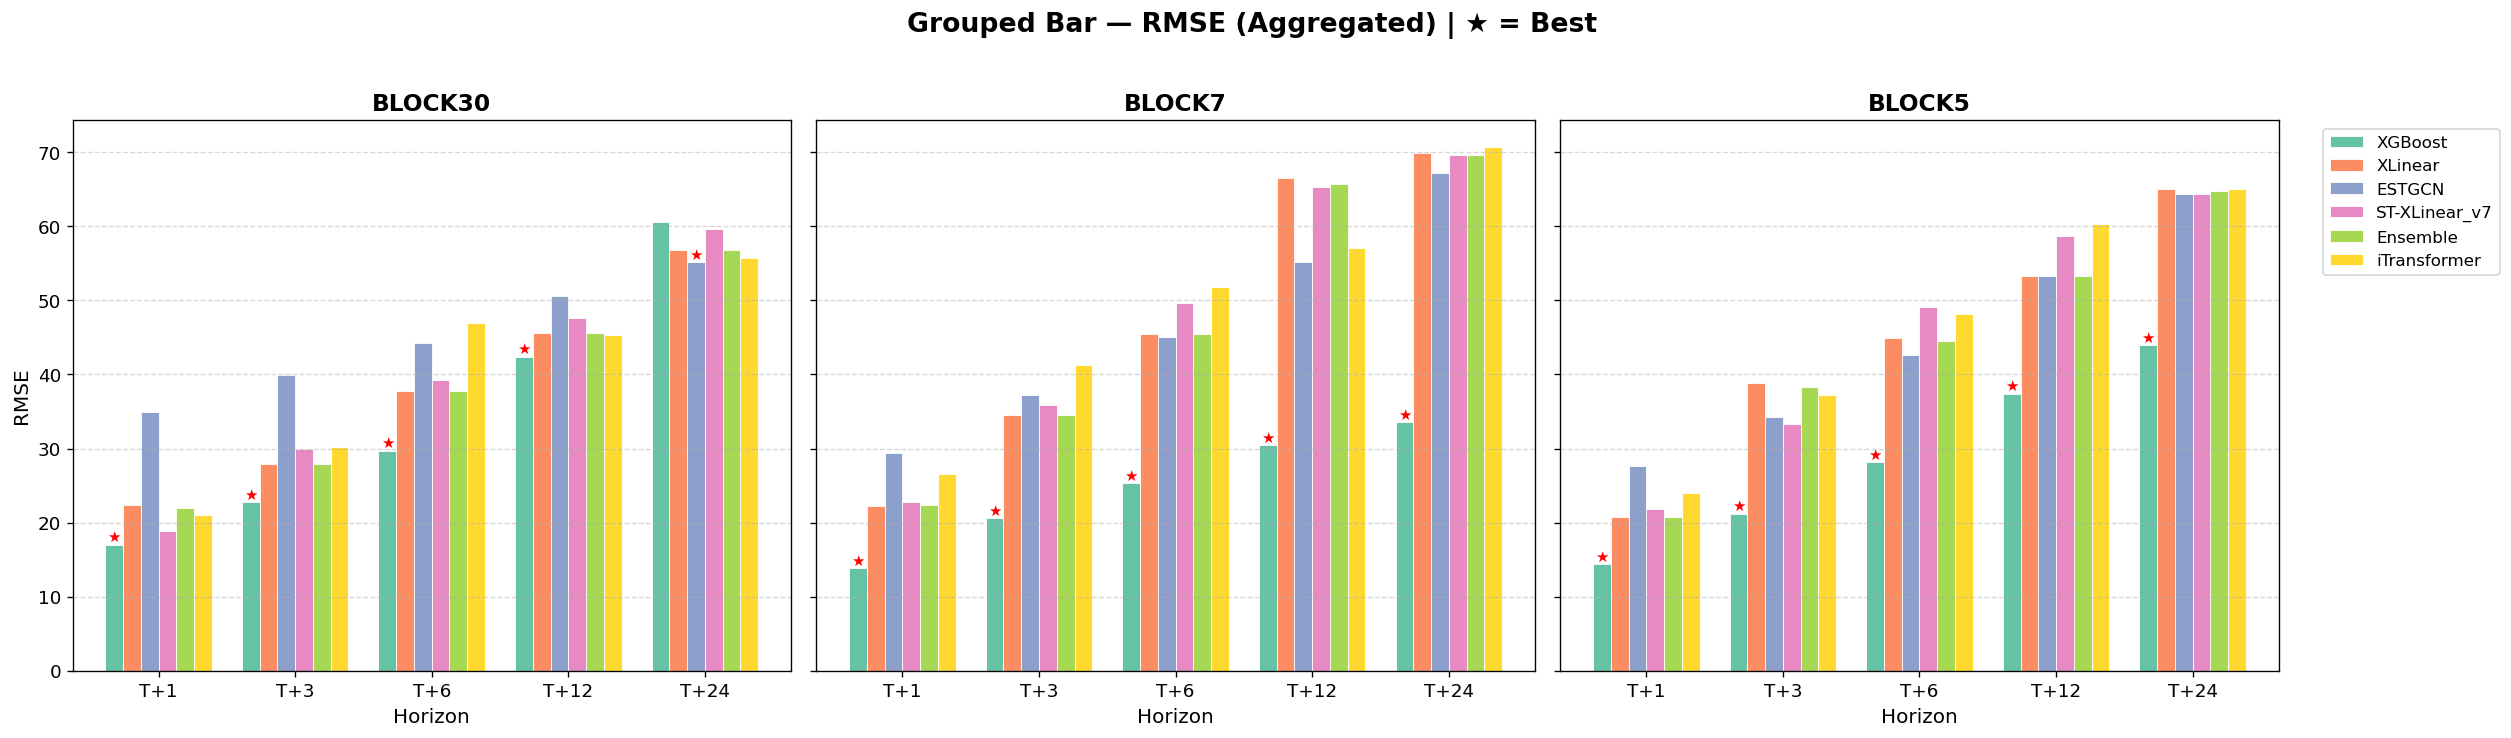

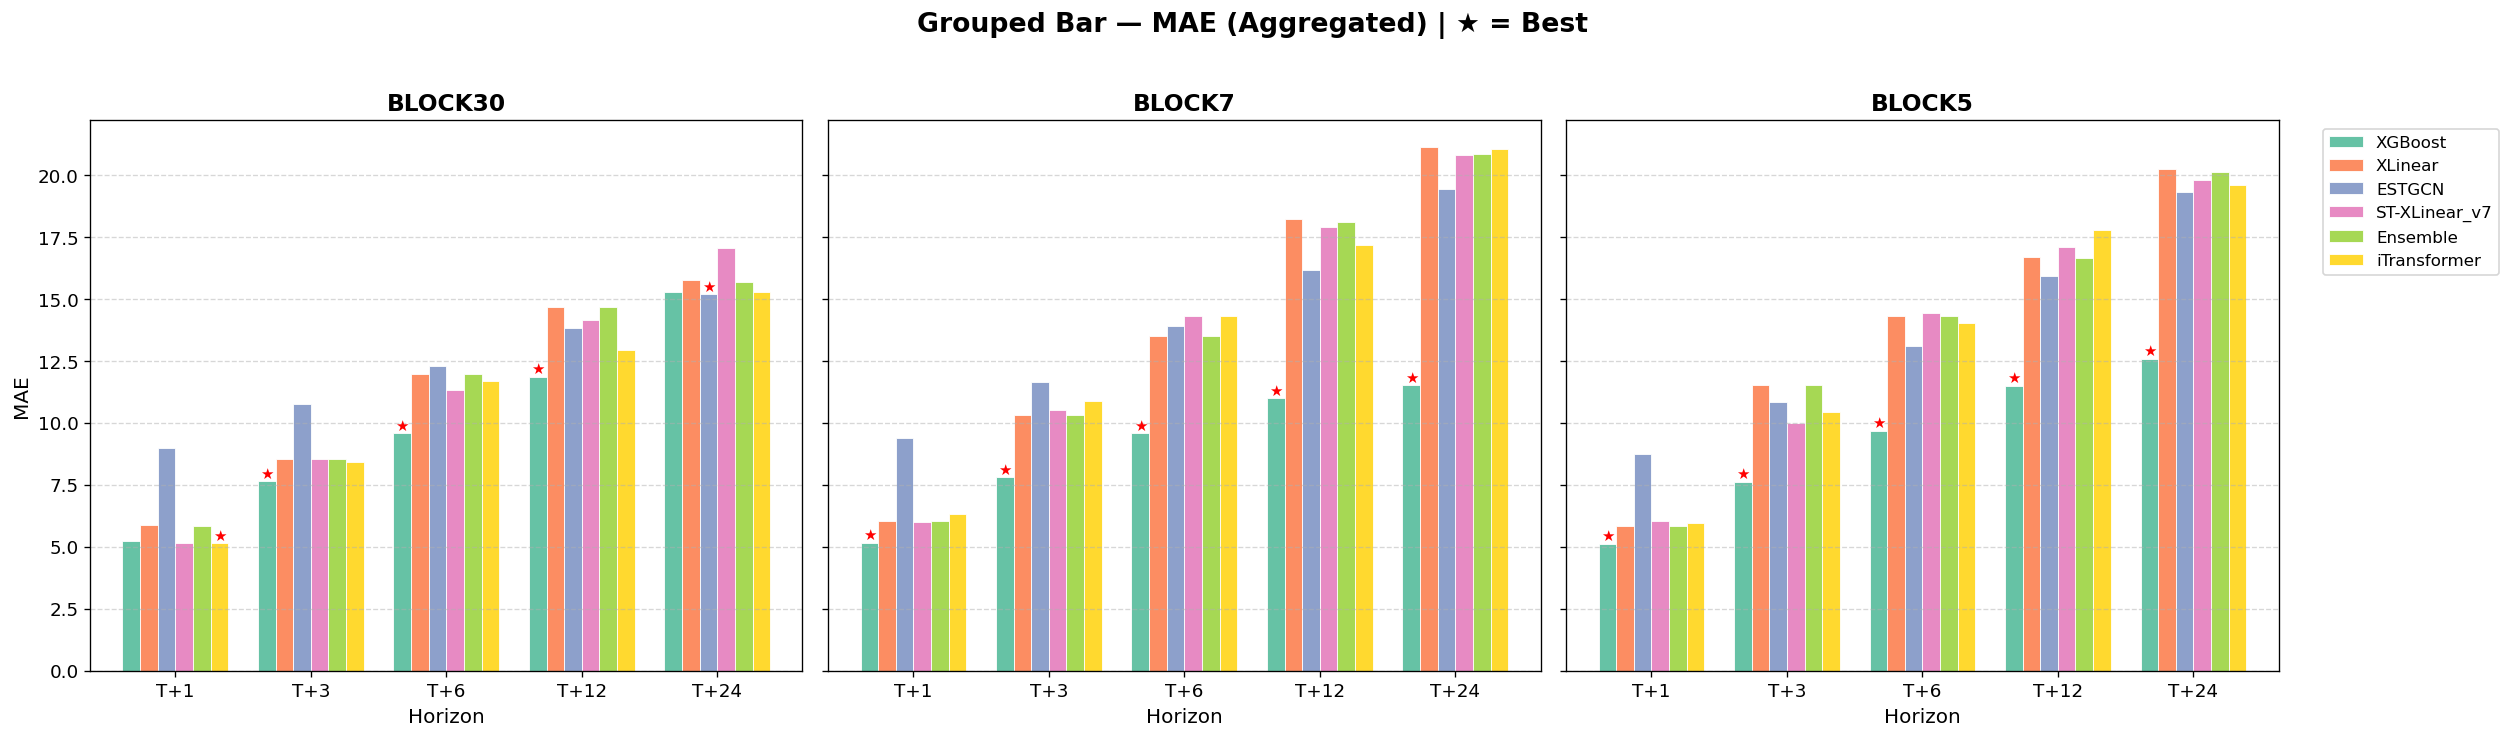

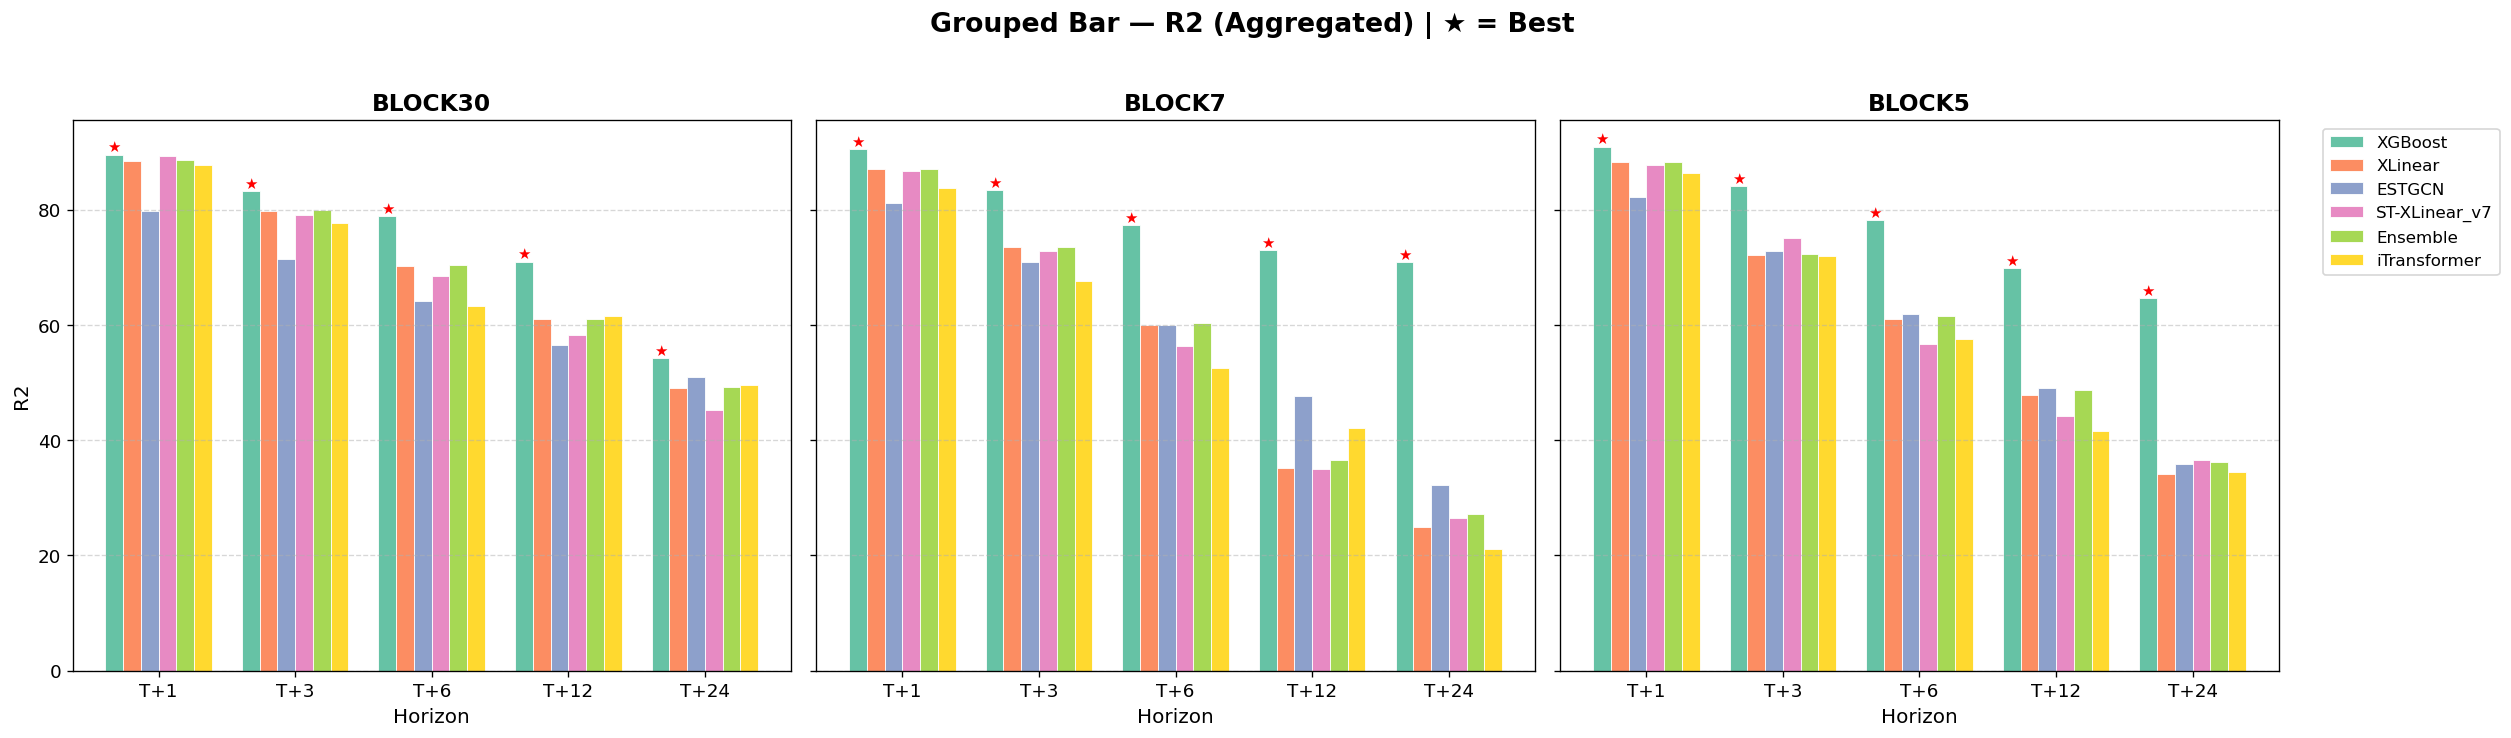

In [15]:
for metric in metrics:
    sub = df[(df['region'] == 'aggregated') & (df['metric'] == metric)]
    
    fig, axes = plt.subplots(1, len(blocks), figsize=(7 * len(blocks), 6), sharey=True)
    if len(blocks) == 1:
        axes = [axes]
    
    colors = sns.color_palette('Set2', len(models))
    
    for b_idx, block in enumerate(blocks):
        ax = axes[b_idx]
        block_data = sub[sub['block'] == block]
        
        x = np.arange(len(horizons))
        width = 0.13
        
        for m_idx, model in enumerate(models):
            vals = block_data[block_data['model'] == model]['value'].values
            offset = (m_idx - len(models)/2 + 0.5) * width
            bars = ax.bar(x + offset, vals, width, label=model, color=colors[m_idx], edgecolor='white', linewidth=0.5)
            
            # Đánh dấu giá trị tốt nhất ở mỗi horizon
            for h_idx in range(len(horizons)):
                h_vals = block_data[block_data['horizon'] == horizons[h_idx]]['value'].values
                best = min(h_vals) if metric_better[metric] == 'lower' else max(h_vals)
                if vals[h_idx] == best:
                    ax.annotate('★', (x[h_idx] + offset, vals[h_idx]),
                               ha='center', va='bottom', fontsize=9, color='red', fontweight='bold')
        
        ax.set_title(f'{block.upper()}', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(horizons)
        ax.set_xlabel('Horizon')
        if b_idx == 0:
            ax.set_ylabel(metric)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        if b_idx == len(blocks) - 1:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.suptitle(f'Grouped Bar — {metric} (Aggregated) | ★ = Best', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

**📝 Cách đọc Grouped Bar:**
- Ngôi sao ★ đỏ = Model tốt nhất tại Horizon đó.
- Nếu 1 model liên tục có ★ ở mọi Horizon, mọi Block → Đó là lựa chọn tối ưu.
- Nếu ★ chia đều giữa 2 model → Cân nhắc Hybrid hoặc chọn theo use case (ngắn hạn vs dài hạn).

---
## 3️⃣ RADAR CHART — Sức mạnh tổng thể
Trung bình R² qua 3 Blocks tại mỗi Horizon. Model nào phình to nhất = tốt nhất toàn diện.

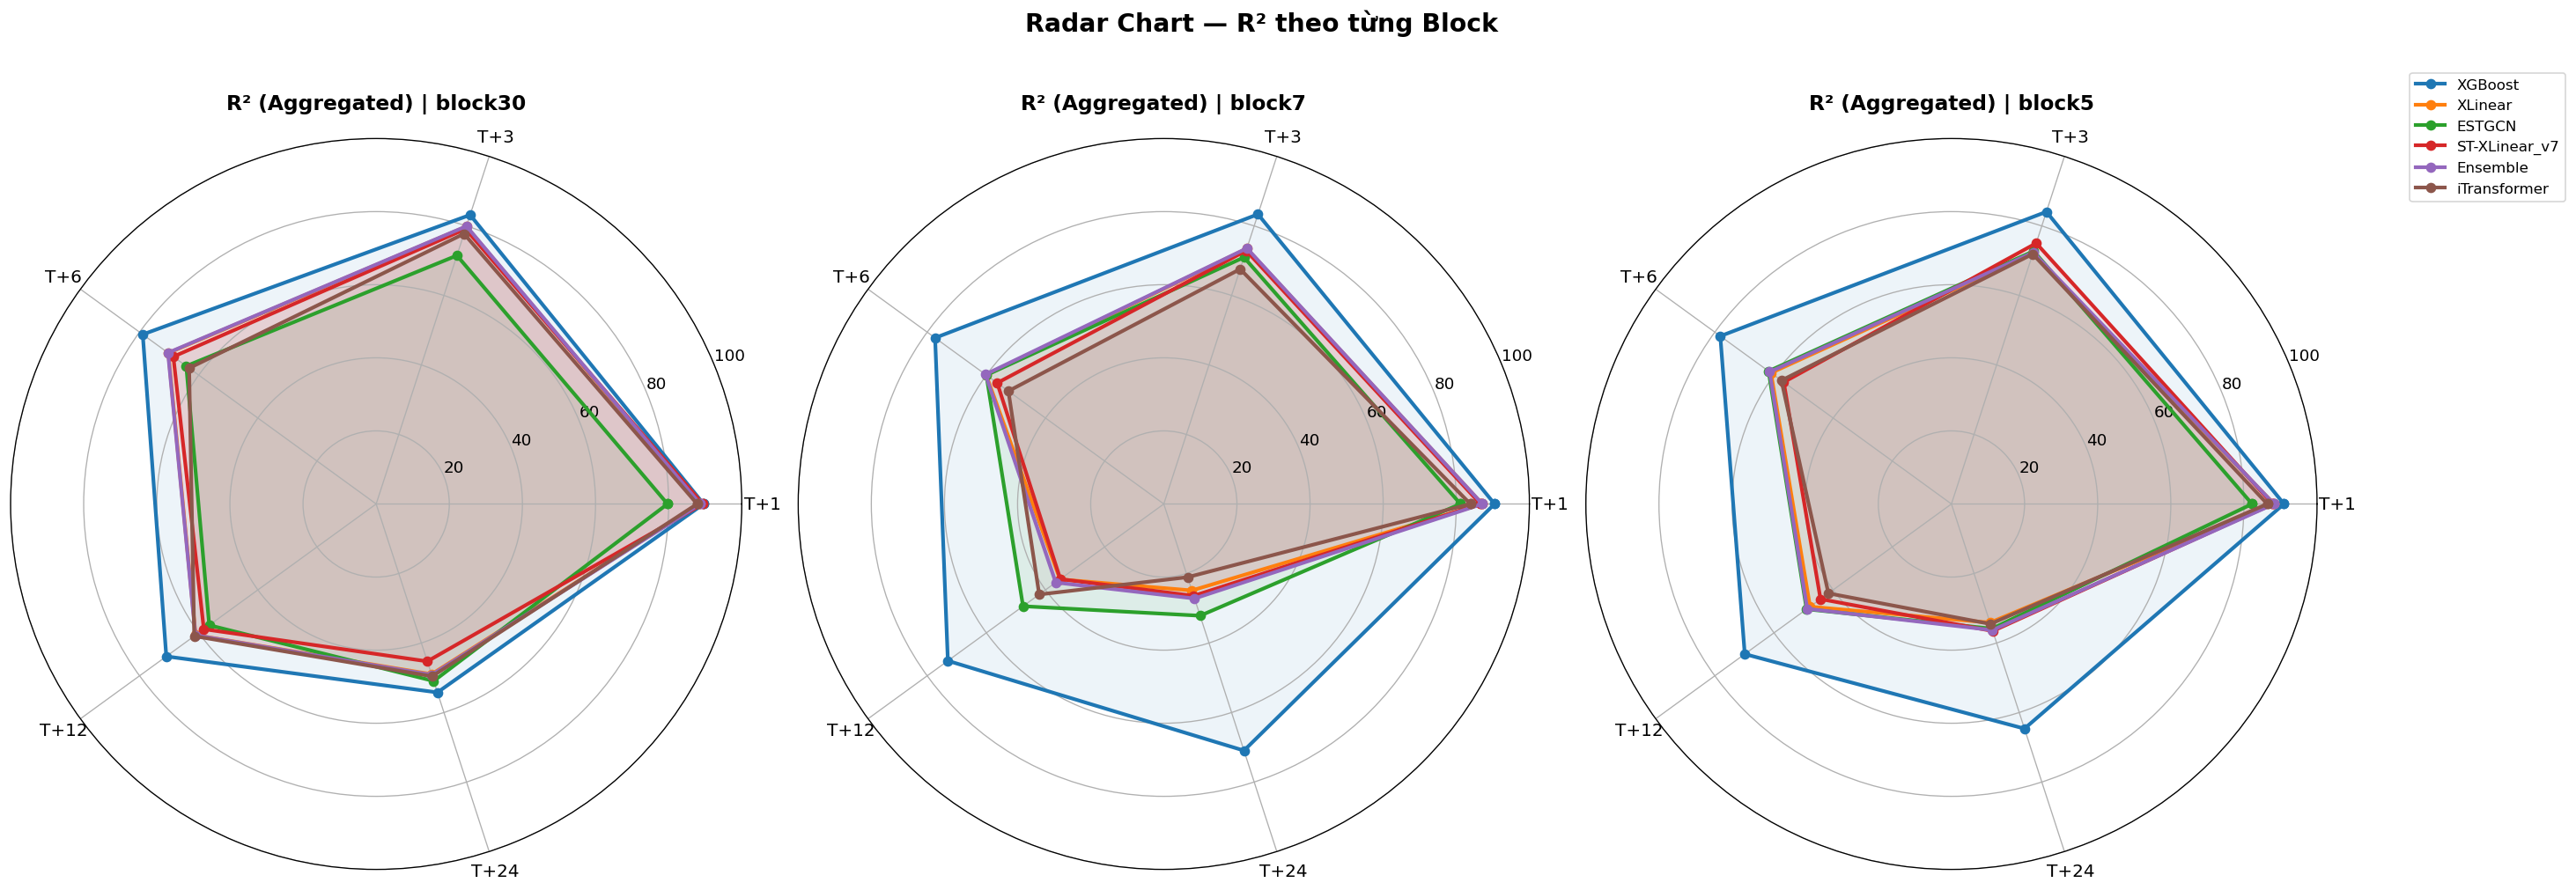

In [17]:
fig, axes = plt.subplots(1, len(blocks), figsize=(8 * len(blocks), 8), subplot_kw=dict(polar=True))
if len(blocks) == 1:
    axes = [axes]

categories = horizons
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # close the polygon

colors = sns.color_palette('tab10', len(models))

for b_idx, block in enumerate(blocks):
    ax = axes[b_idx]
    r2_block = df[
        (df['region'] == 'aggregated') &
        (df['metric'] == 'R2') &
        (df['block'] == block)
    ]

    for i, model in enumerate(models):
        values = []
        for h in horizons:
            v = r2_block[
                (r2_block['model'] == model) &
                (r2_block['horizon'] == h)
            ]['value'].values
            values.append(v[0] if len(v) > 0 else 0)
        values += values[:1]

        ax.plot(angles, values, 'o-', linewidth=2.5, label=model, color=colors[i], markersize=6)
        ax.fill(angles, values, alpha=0.08, color=colors[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=12)
    ax.set_ylim(0, 100)
    ax.set_title(f'R² (Aggregated) | {block}', fontsize=14, fontweight='bold', pad=20)

axes[-1].legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.suptitle('Radar Chart — R² theo từng Block', fontsize=17, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

**📝 Cách đọc Radar:**
- Diện tích đa giác càng lớn → Model càng tốt toàn diện.
- Nếu đa giác bị "lõm" sâu ở 1 đỉnh (ví dụ T+24) → Model yếu ở dải dự báo dài.
- XGBoost thường có hình tròn đều nhất (robustness), iTransformer thường nhọn ở T+1 nhưng tụt nhanh.

---
## 4️⃣ BOX PLOT — Đo độ ổn định xuyên Block
Gom **tất cả** giá trị của 1 Model (qua 3 Blocks × 3 Regions × 5 Horizons) lại thành 1 Box.
- Box **ngắn** (IQR nhỏ) = Model **ổn định**, ít bị ảnh hưởng bởi data shift.
- Box **dài** = Model **nhạy cảm**, performance dao động mạnh.

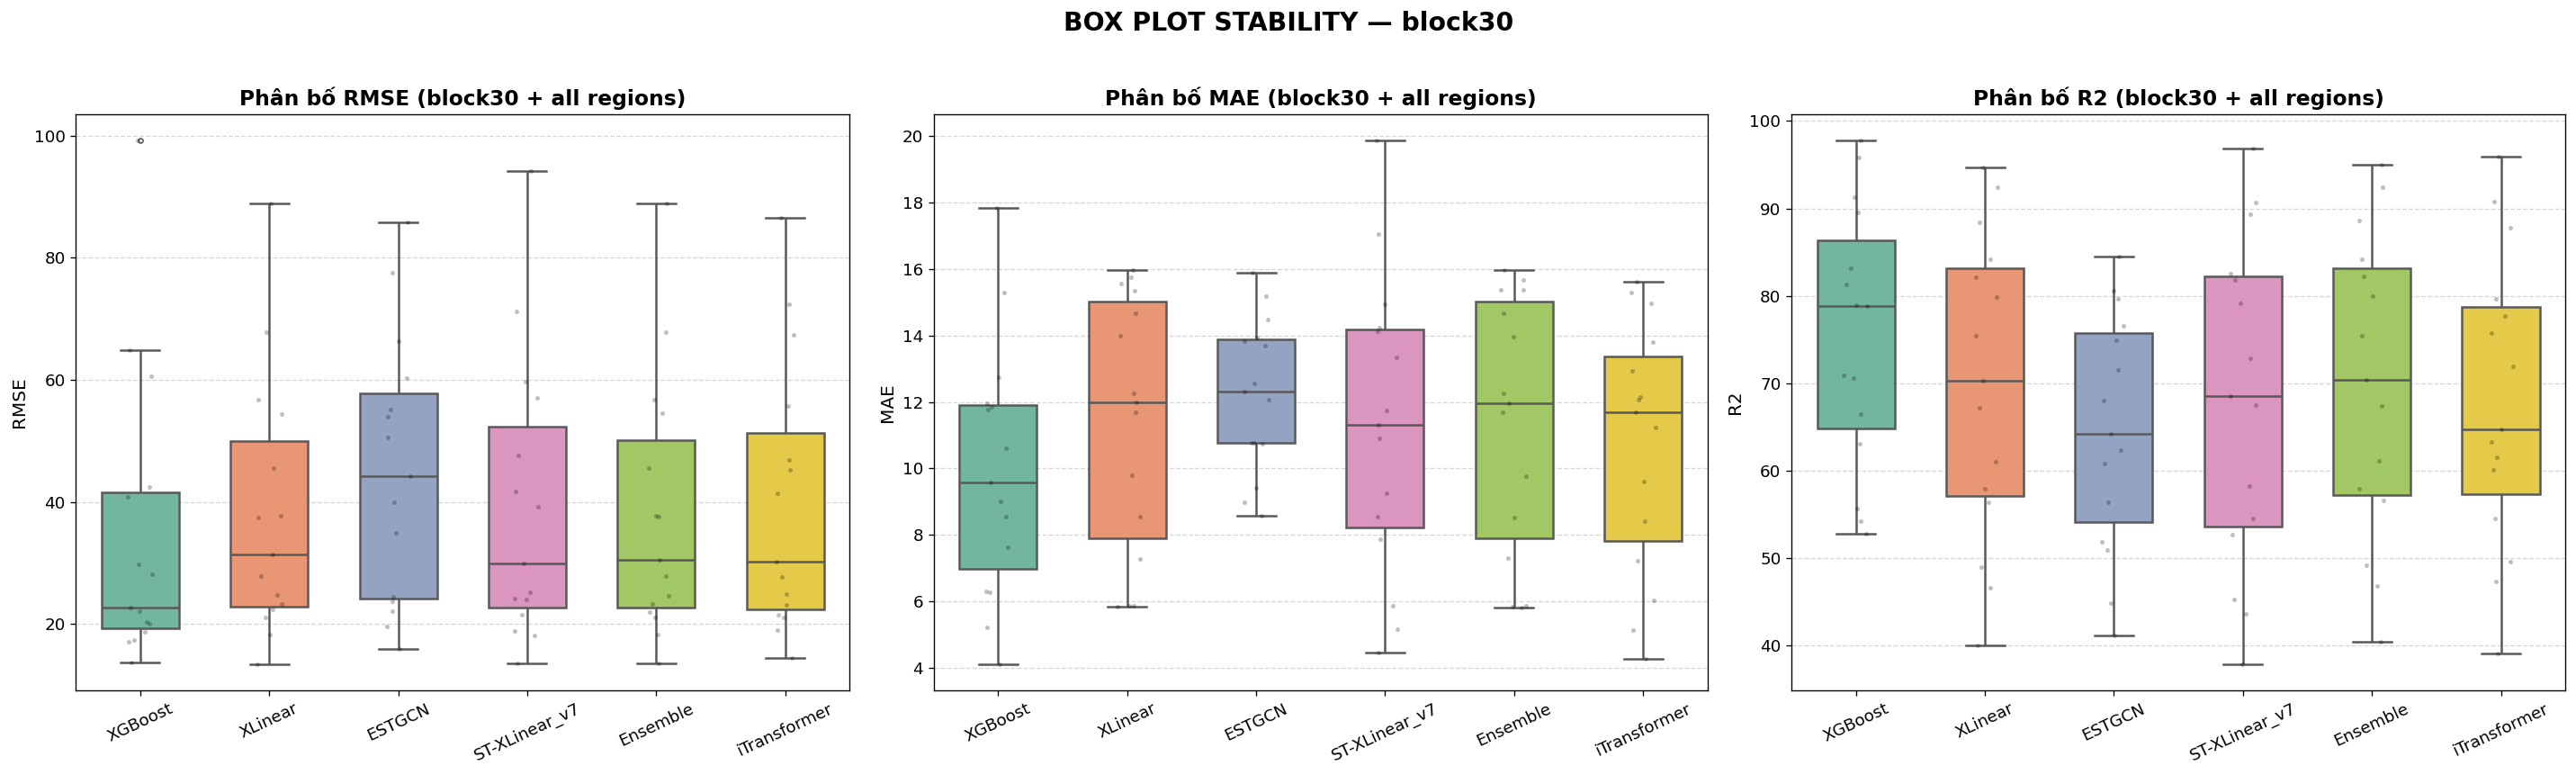

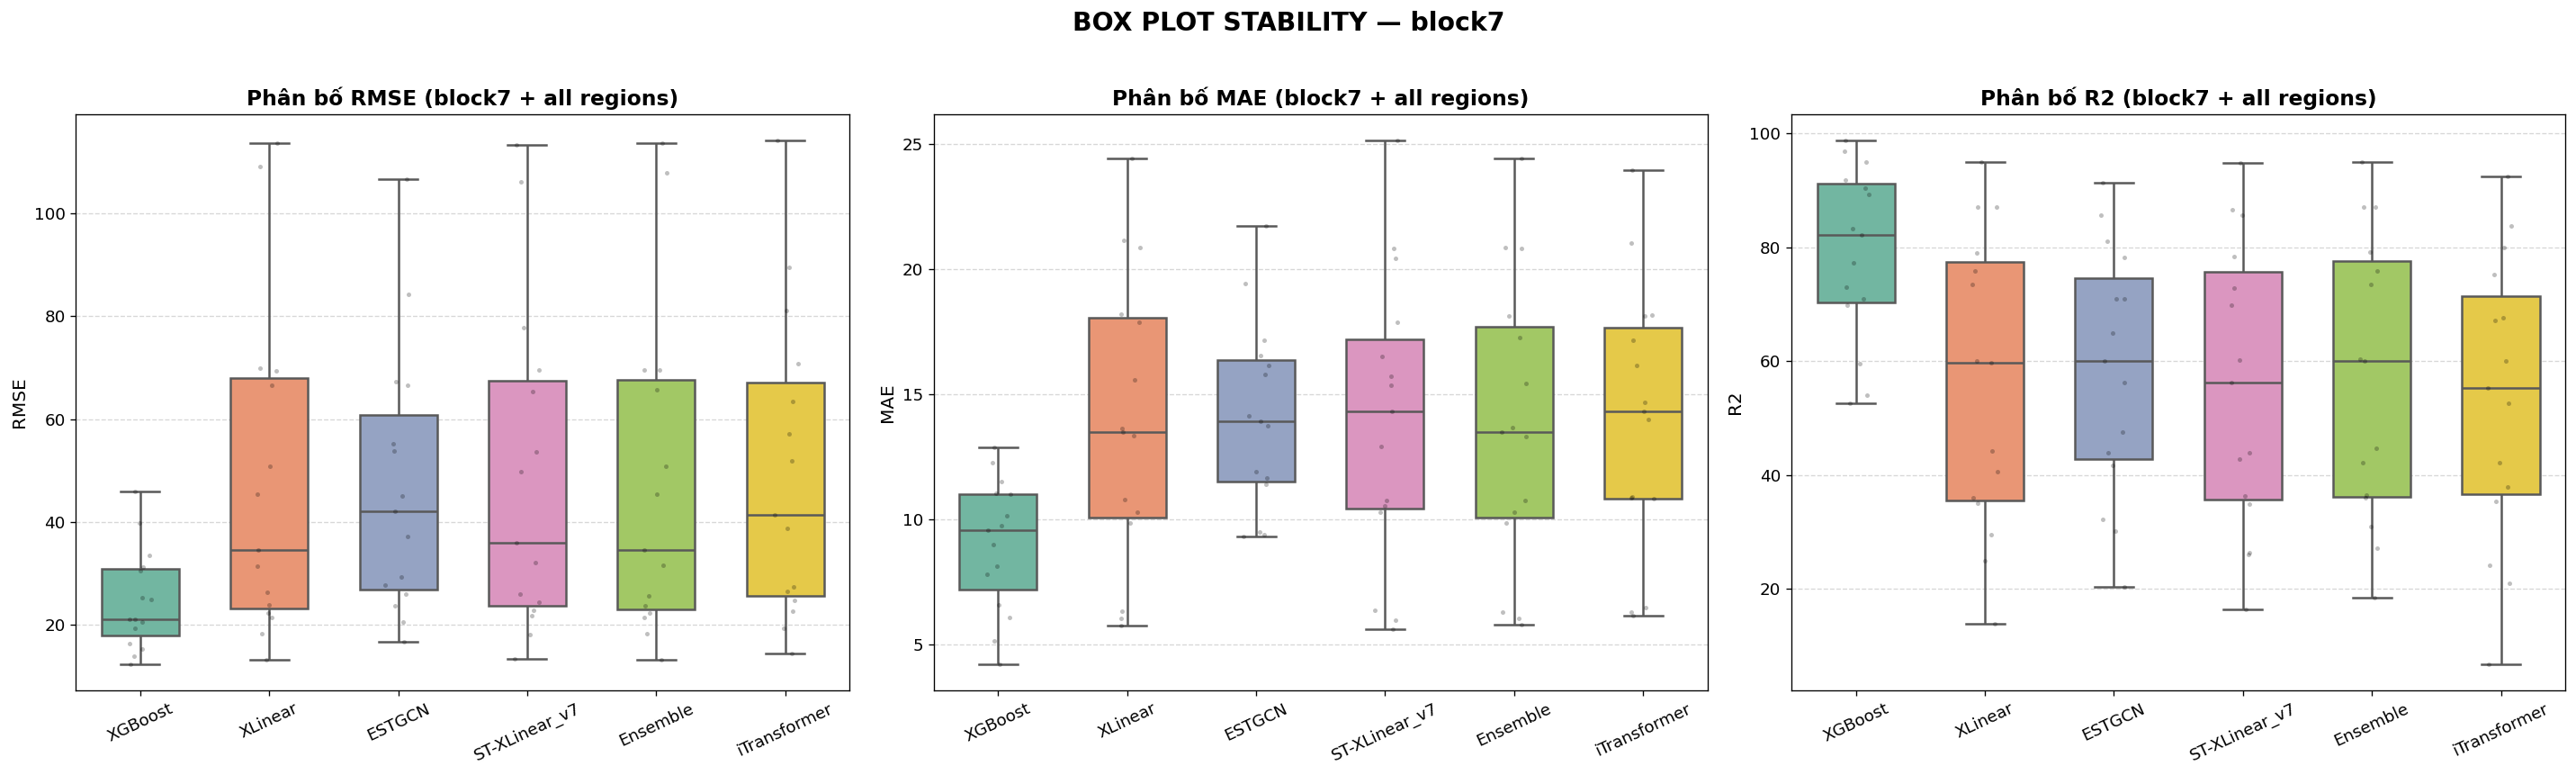

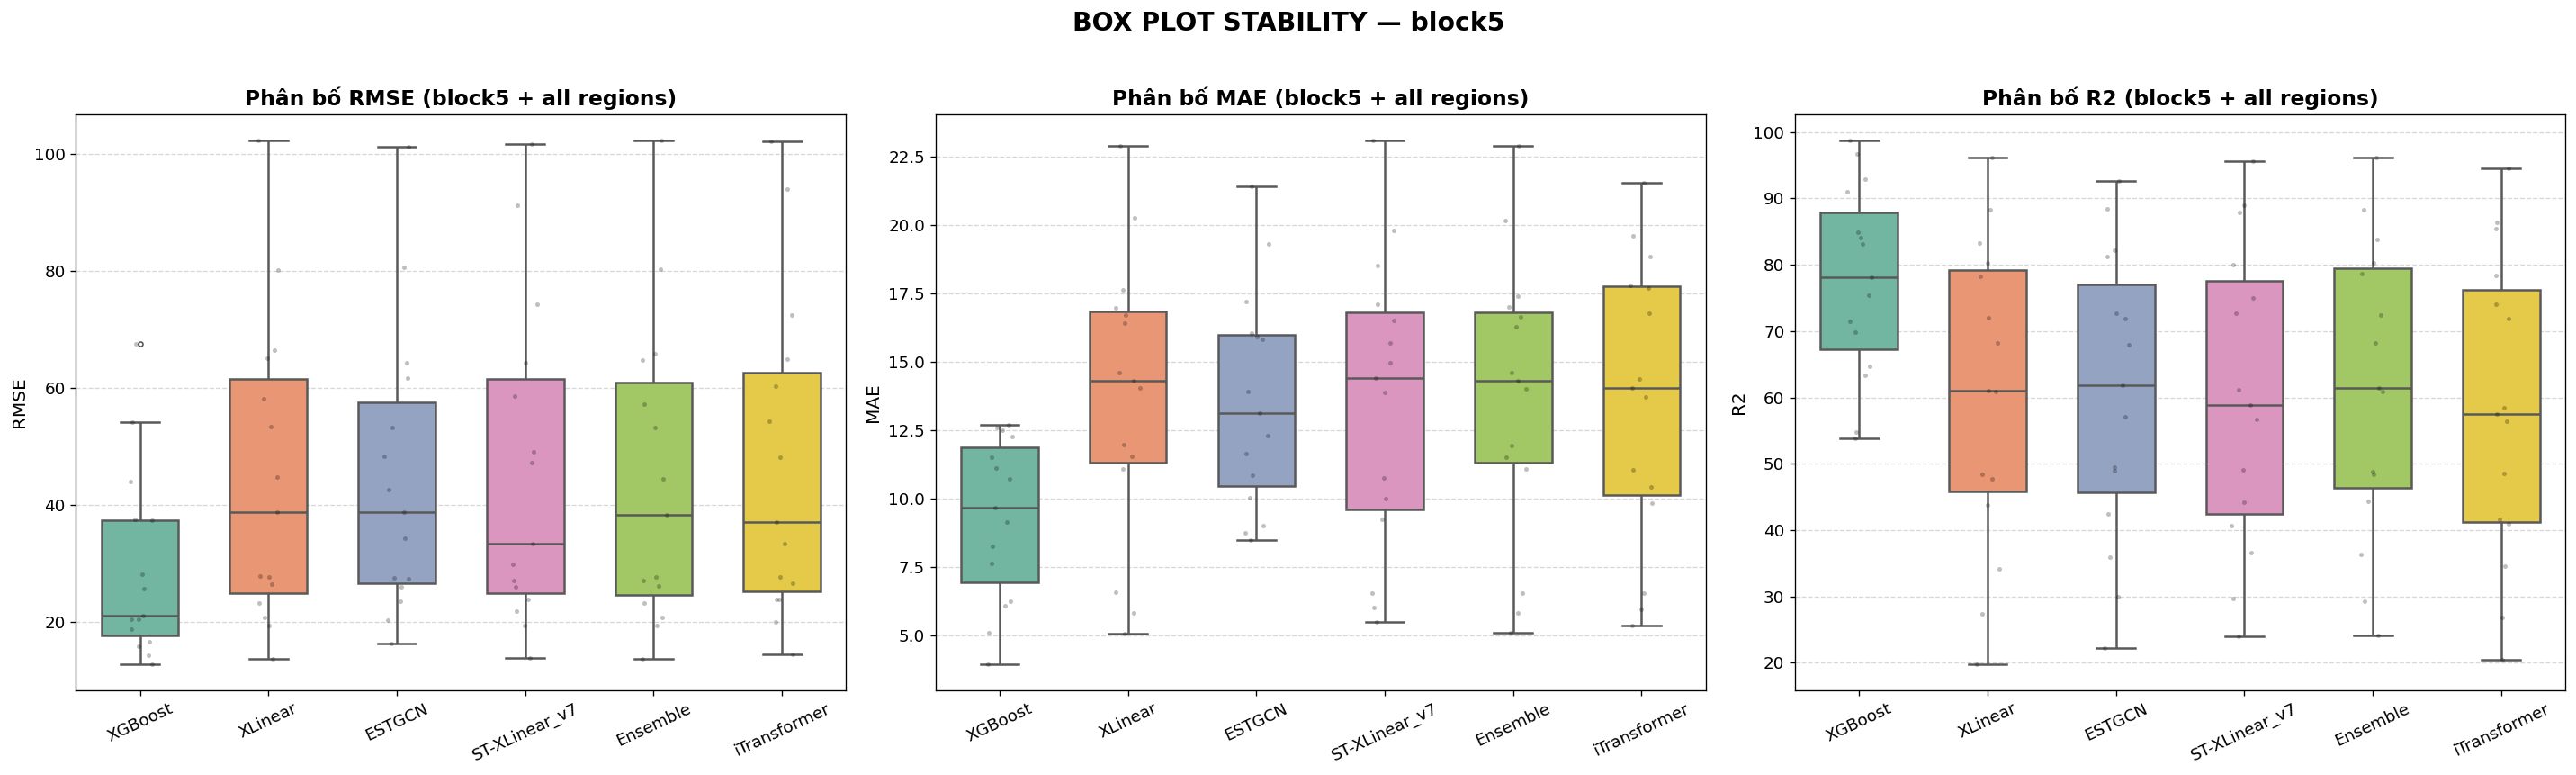

In [14]:
palette = sns.color_palette('Set2', len(models))

for block in blocks:
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))

    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        sub = df[(df['metric'] == metric) & (df['block'] == block)]

        sns.boxplot(data=sub, x='model', y='value', ax=ax, palette=palette,
                    width=0.6, fliersize=3, linewidth=1.5)

        # Overlay stripplot để thấy rõ phân bố
        sns.stripplot(data=sub, x='model', y='value', ax=ax,
                      color='black', alpha=0.25, size=3, jitter=True)

        ax.set_title(f'Phân bố {metric} ({block} + all regions)', fontsize=14, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel(metric)
        ax.tick_params(axis='x', rotation=25)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    plt.suptitle(f'BOX PLOT STABILITY — {block}', fontsize=17, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

**📝 Cách đọc Box Plot:**
- **Median (vạch nằm ngang giữa box):** Giá trị trung vị của model qua tất cả điều kiện.
- **Chiều cao Box (IQR):** Phạm vi dao động. Càng ngắn = Model càng consistent.
- **Whiskers & Outliers:** Cho thấy trường hợp cực đoan (model bị sụp ở 1 block/region cụ thể).
- Với R²: Median cao + Box ngắn = Lý tưởng. Với MAE/RMSE: Median thấp + Box ngắn = Lý tưởng.

---
## 5️⃣ LINE PLOT CHI TIẾT — Phân tích sâu Bắc/Nam/TB từng Block
Mỗi Block = 1 figure khổng lồ gồm 3 hàng (RMSE, MAE, R²) × 3 cột (Bắc, Nam, TB).

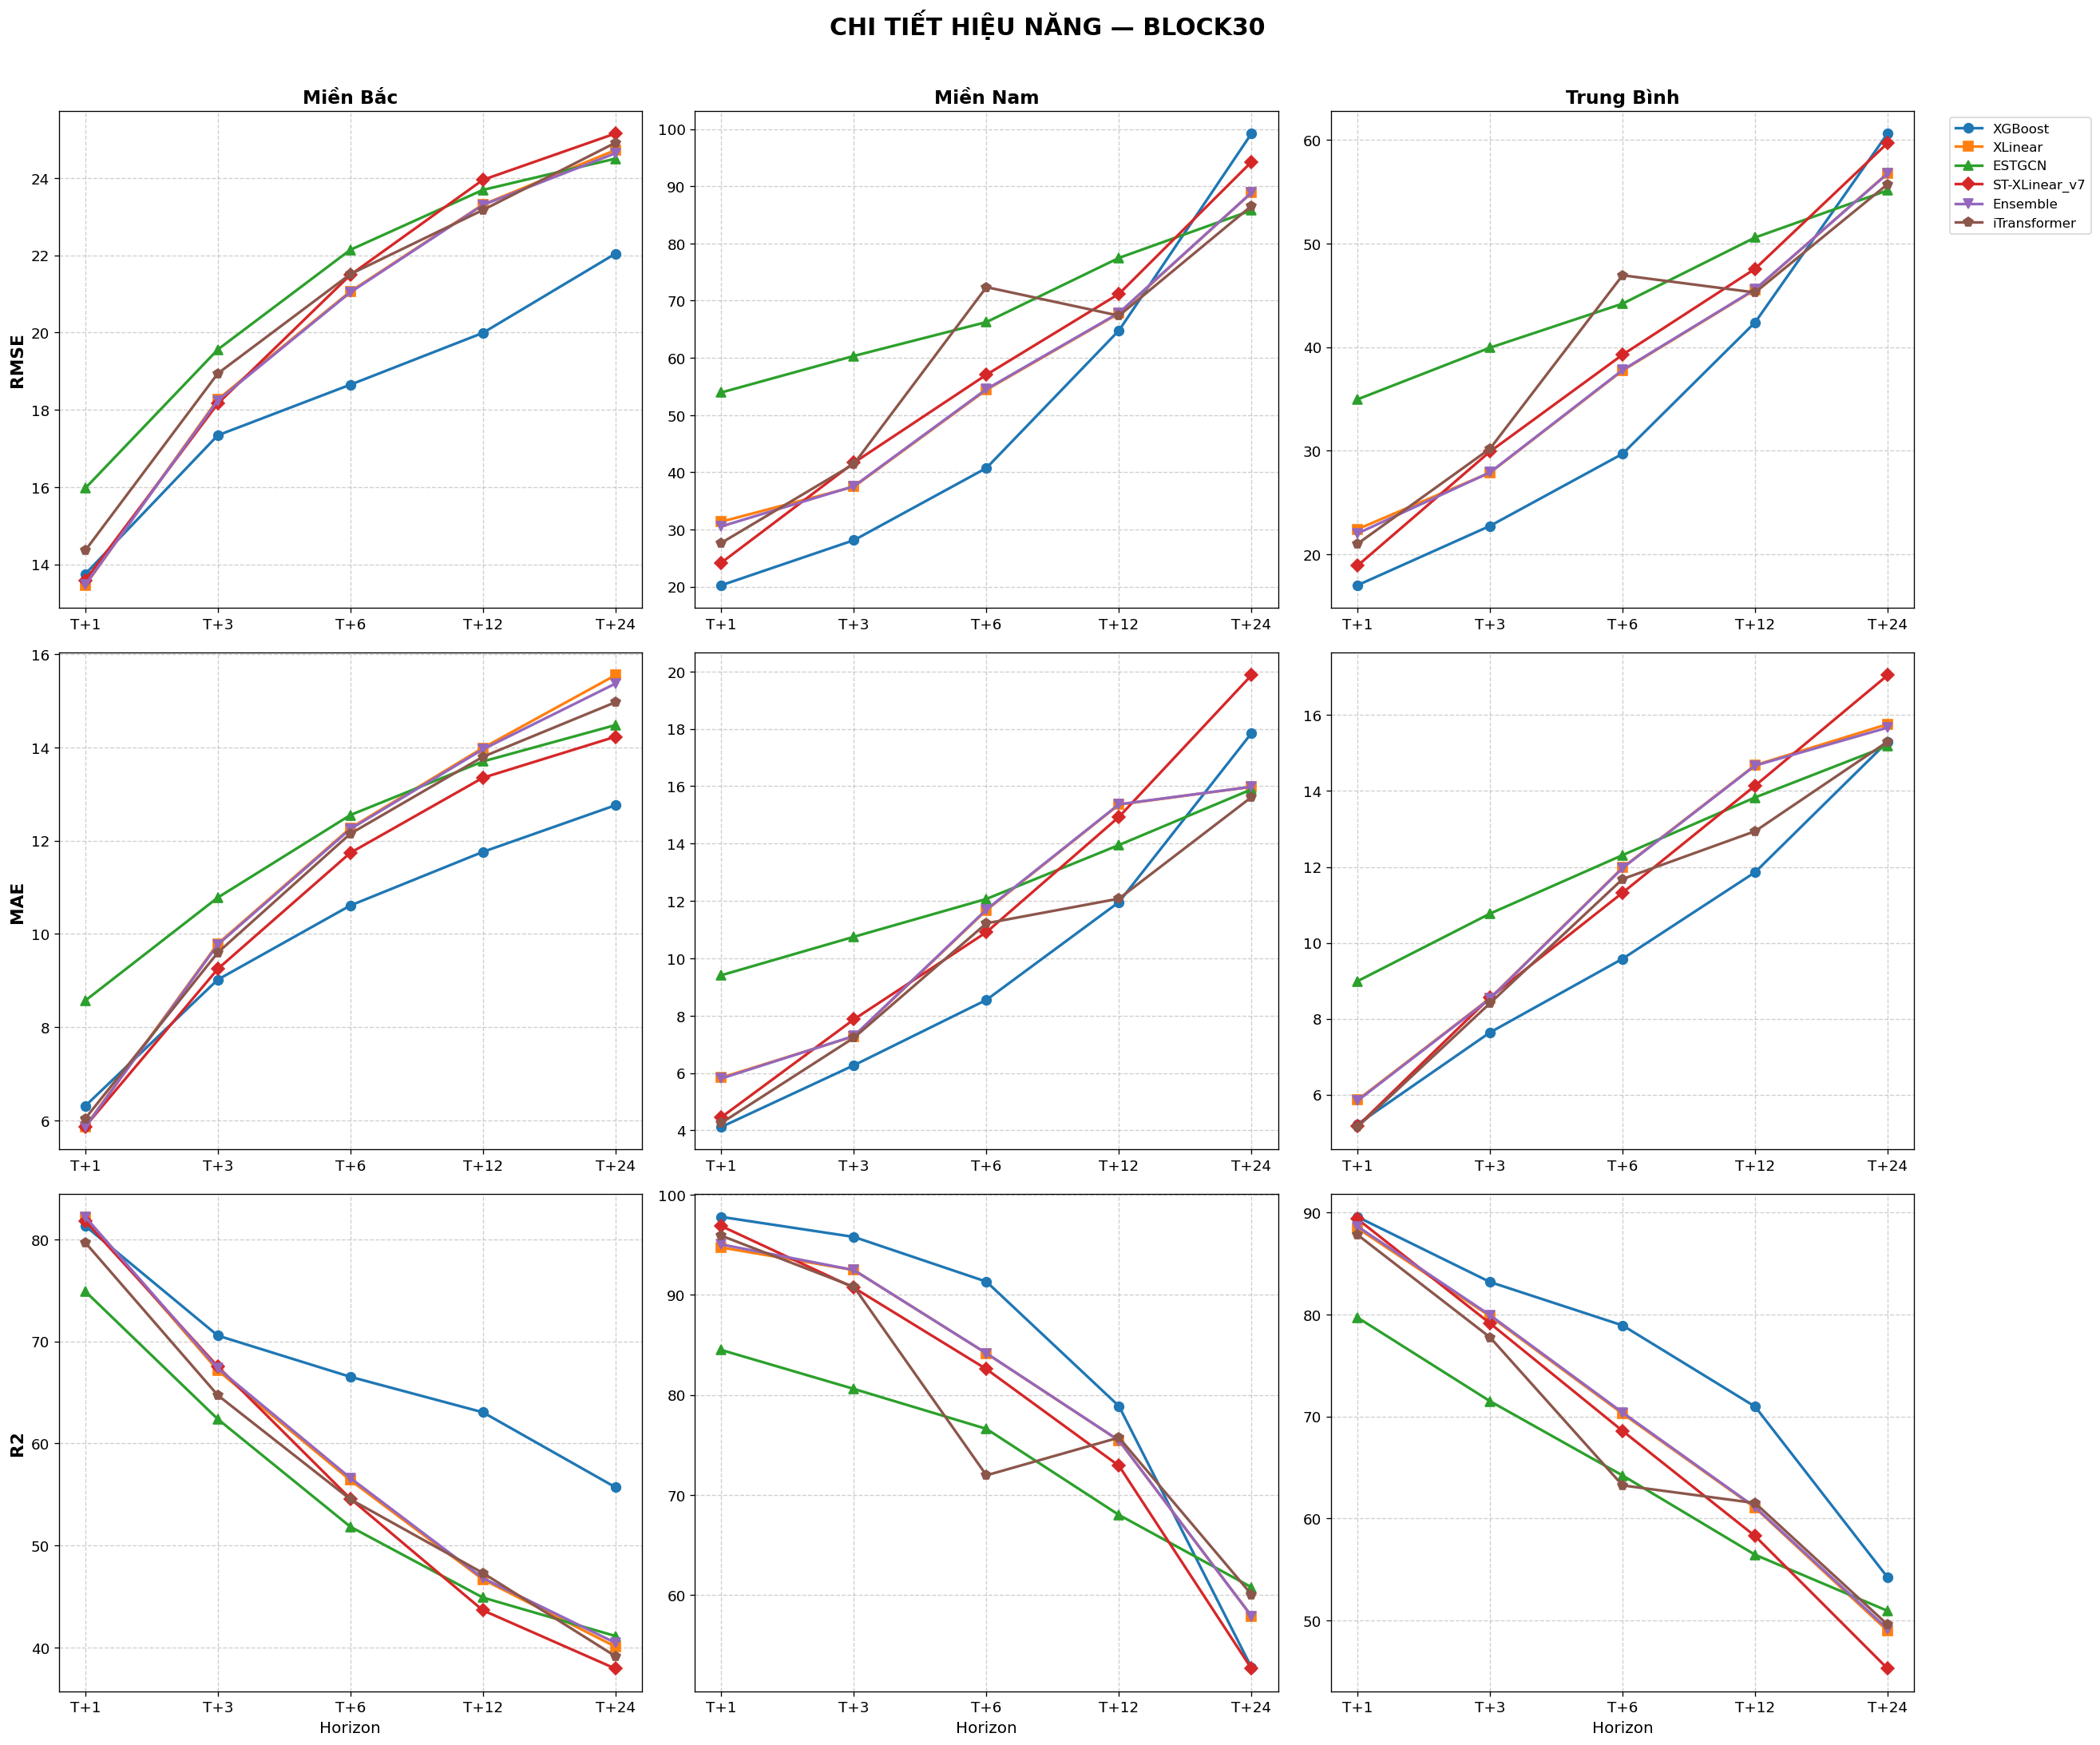

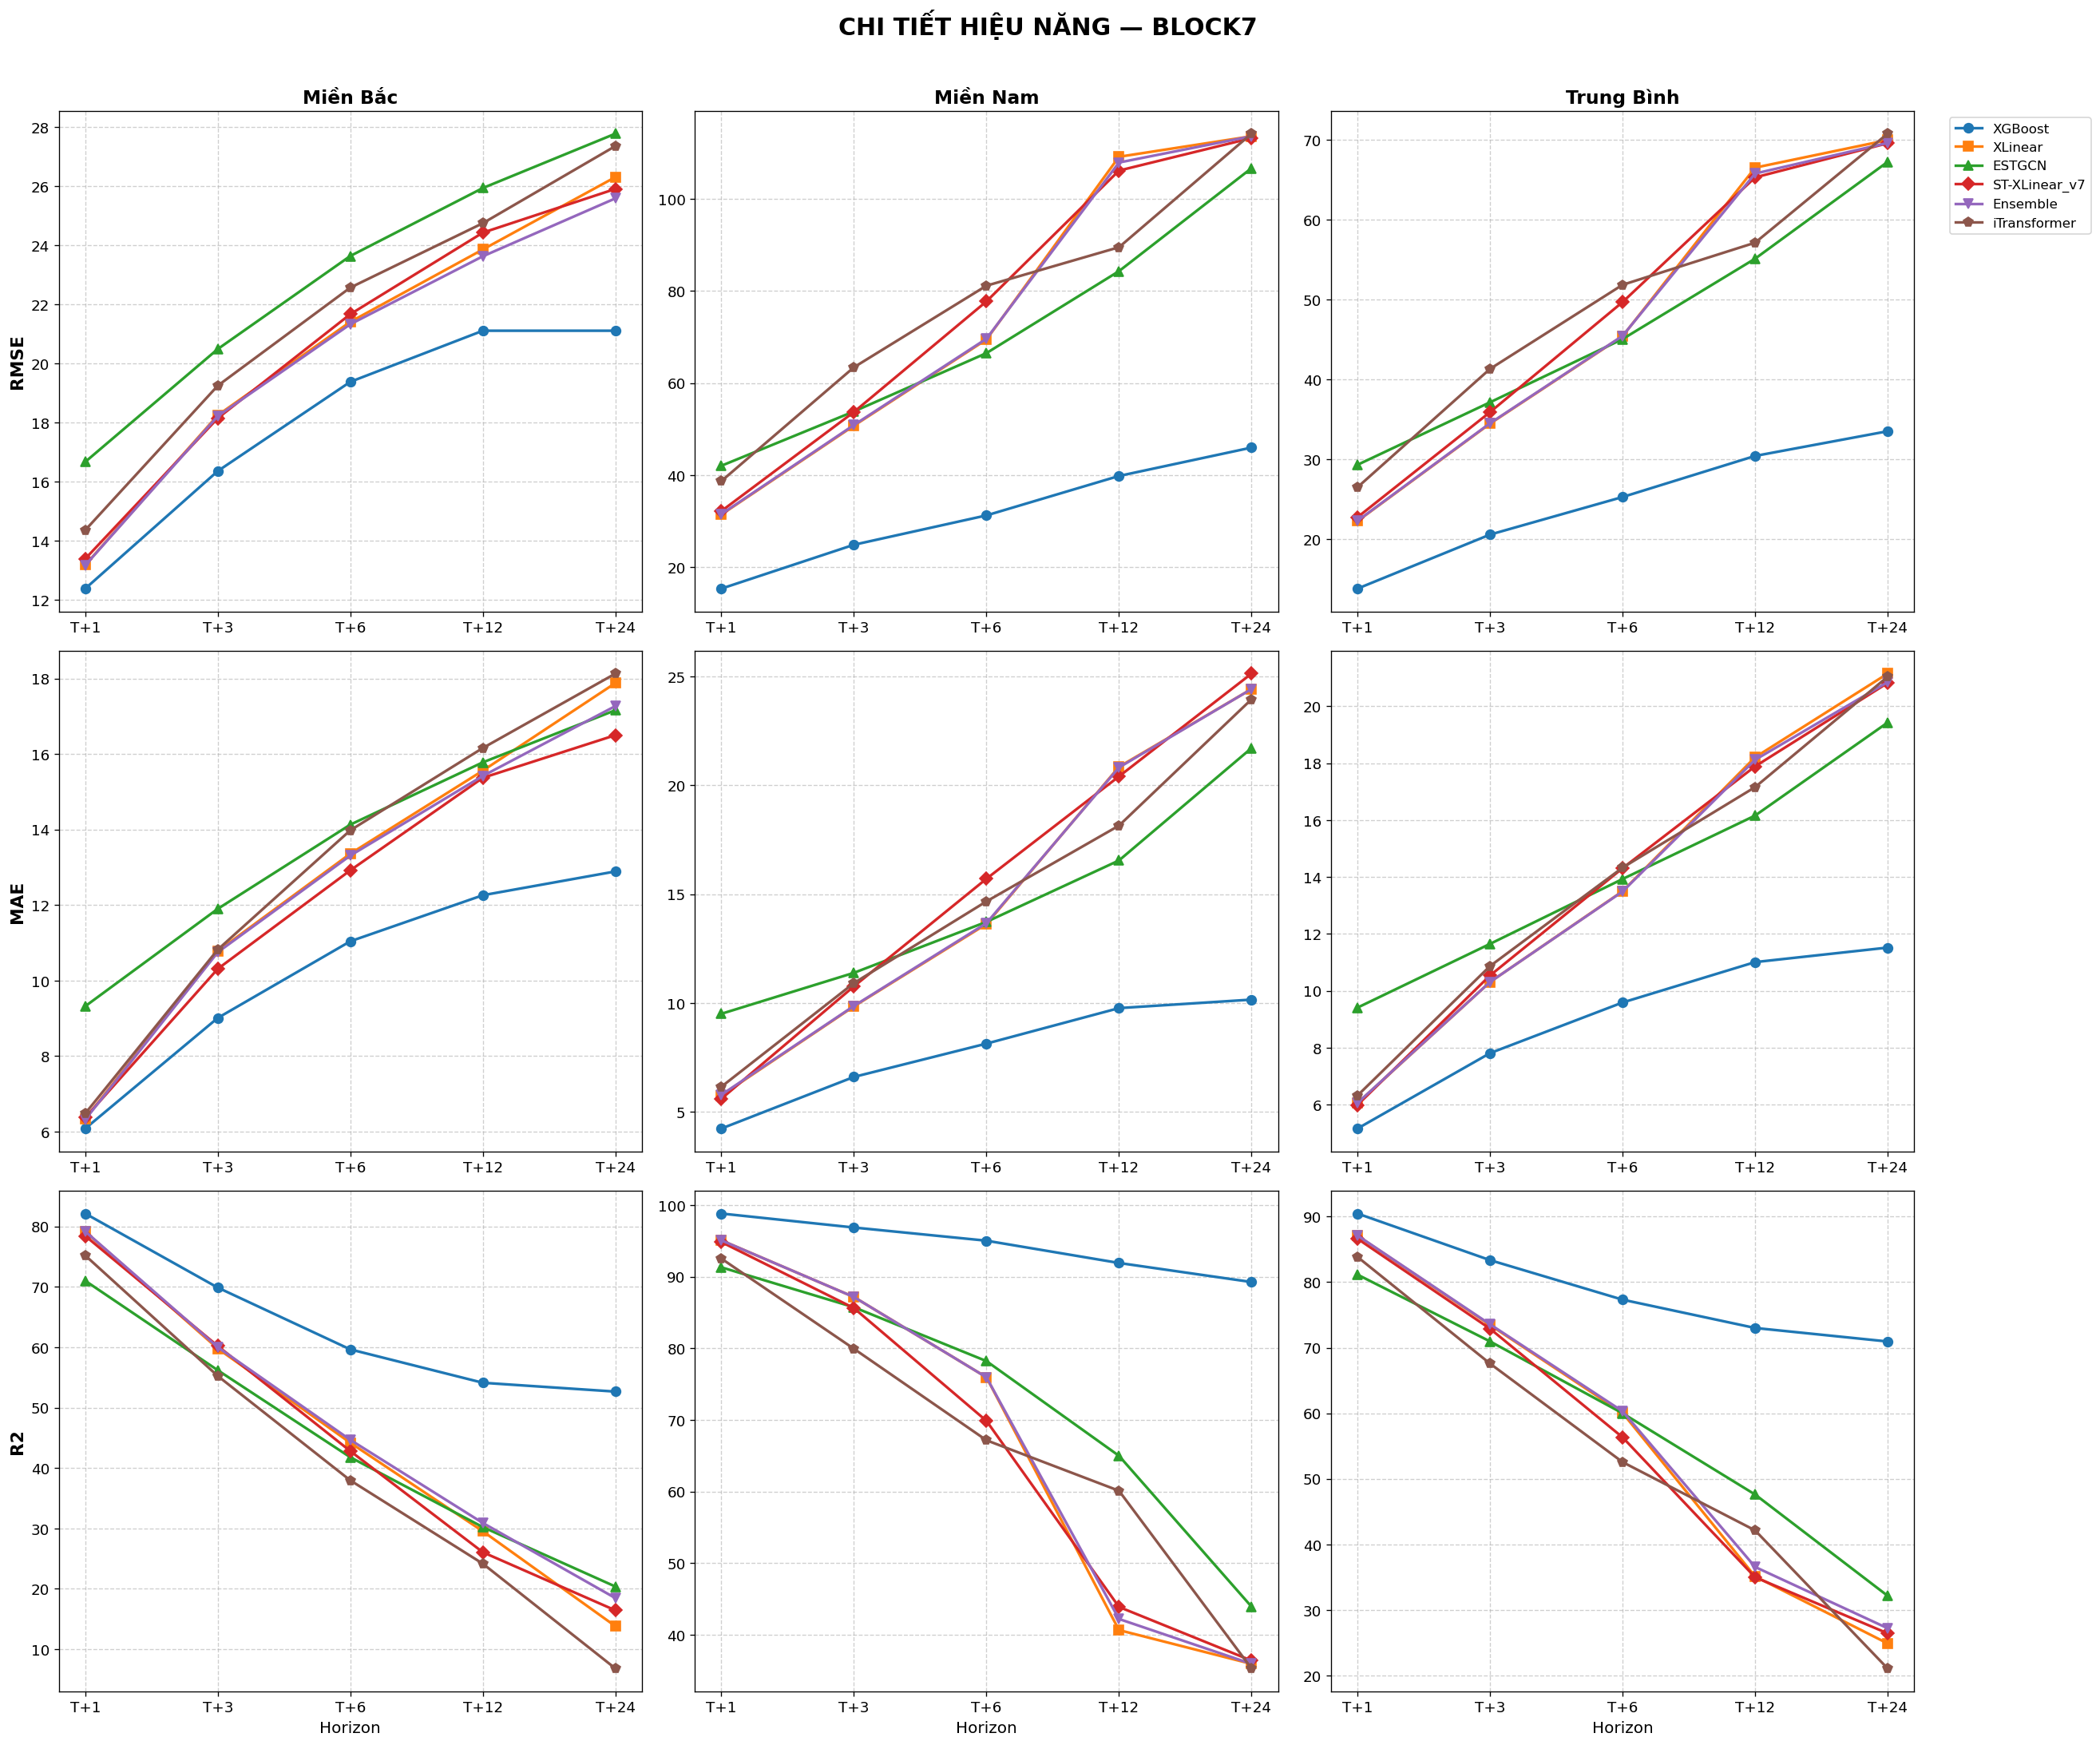

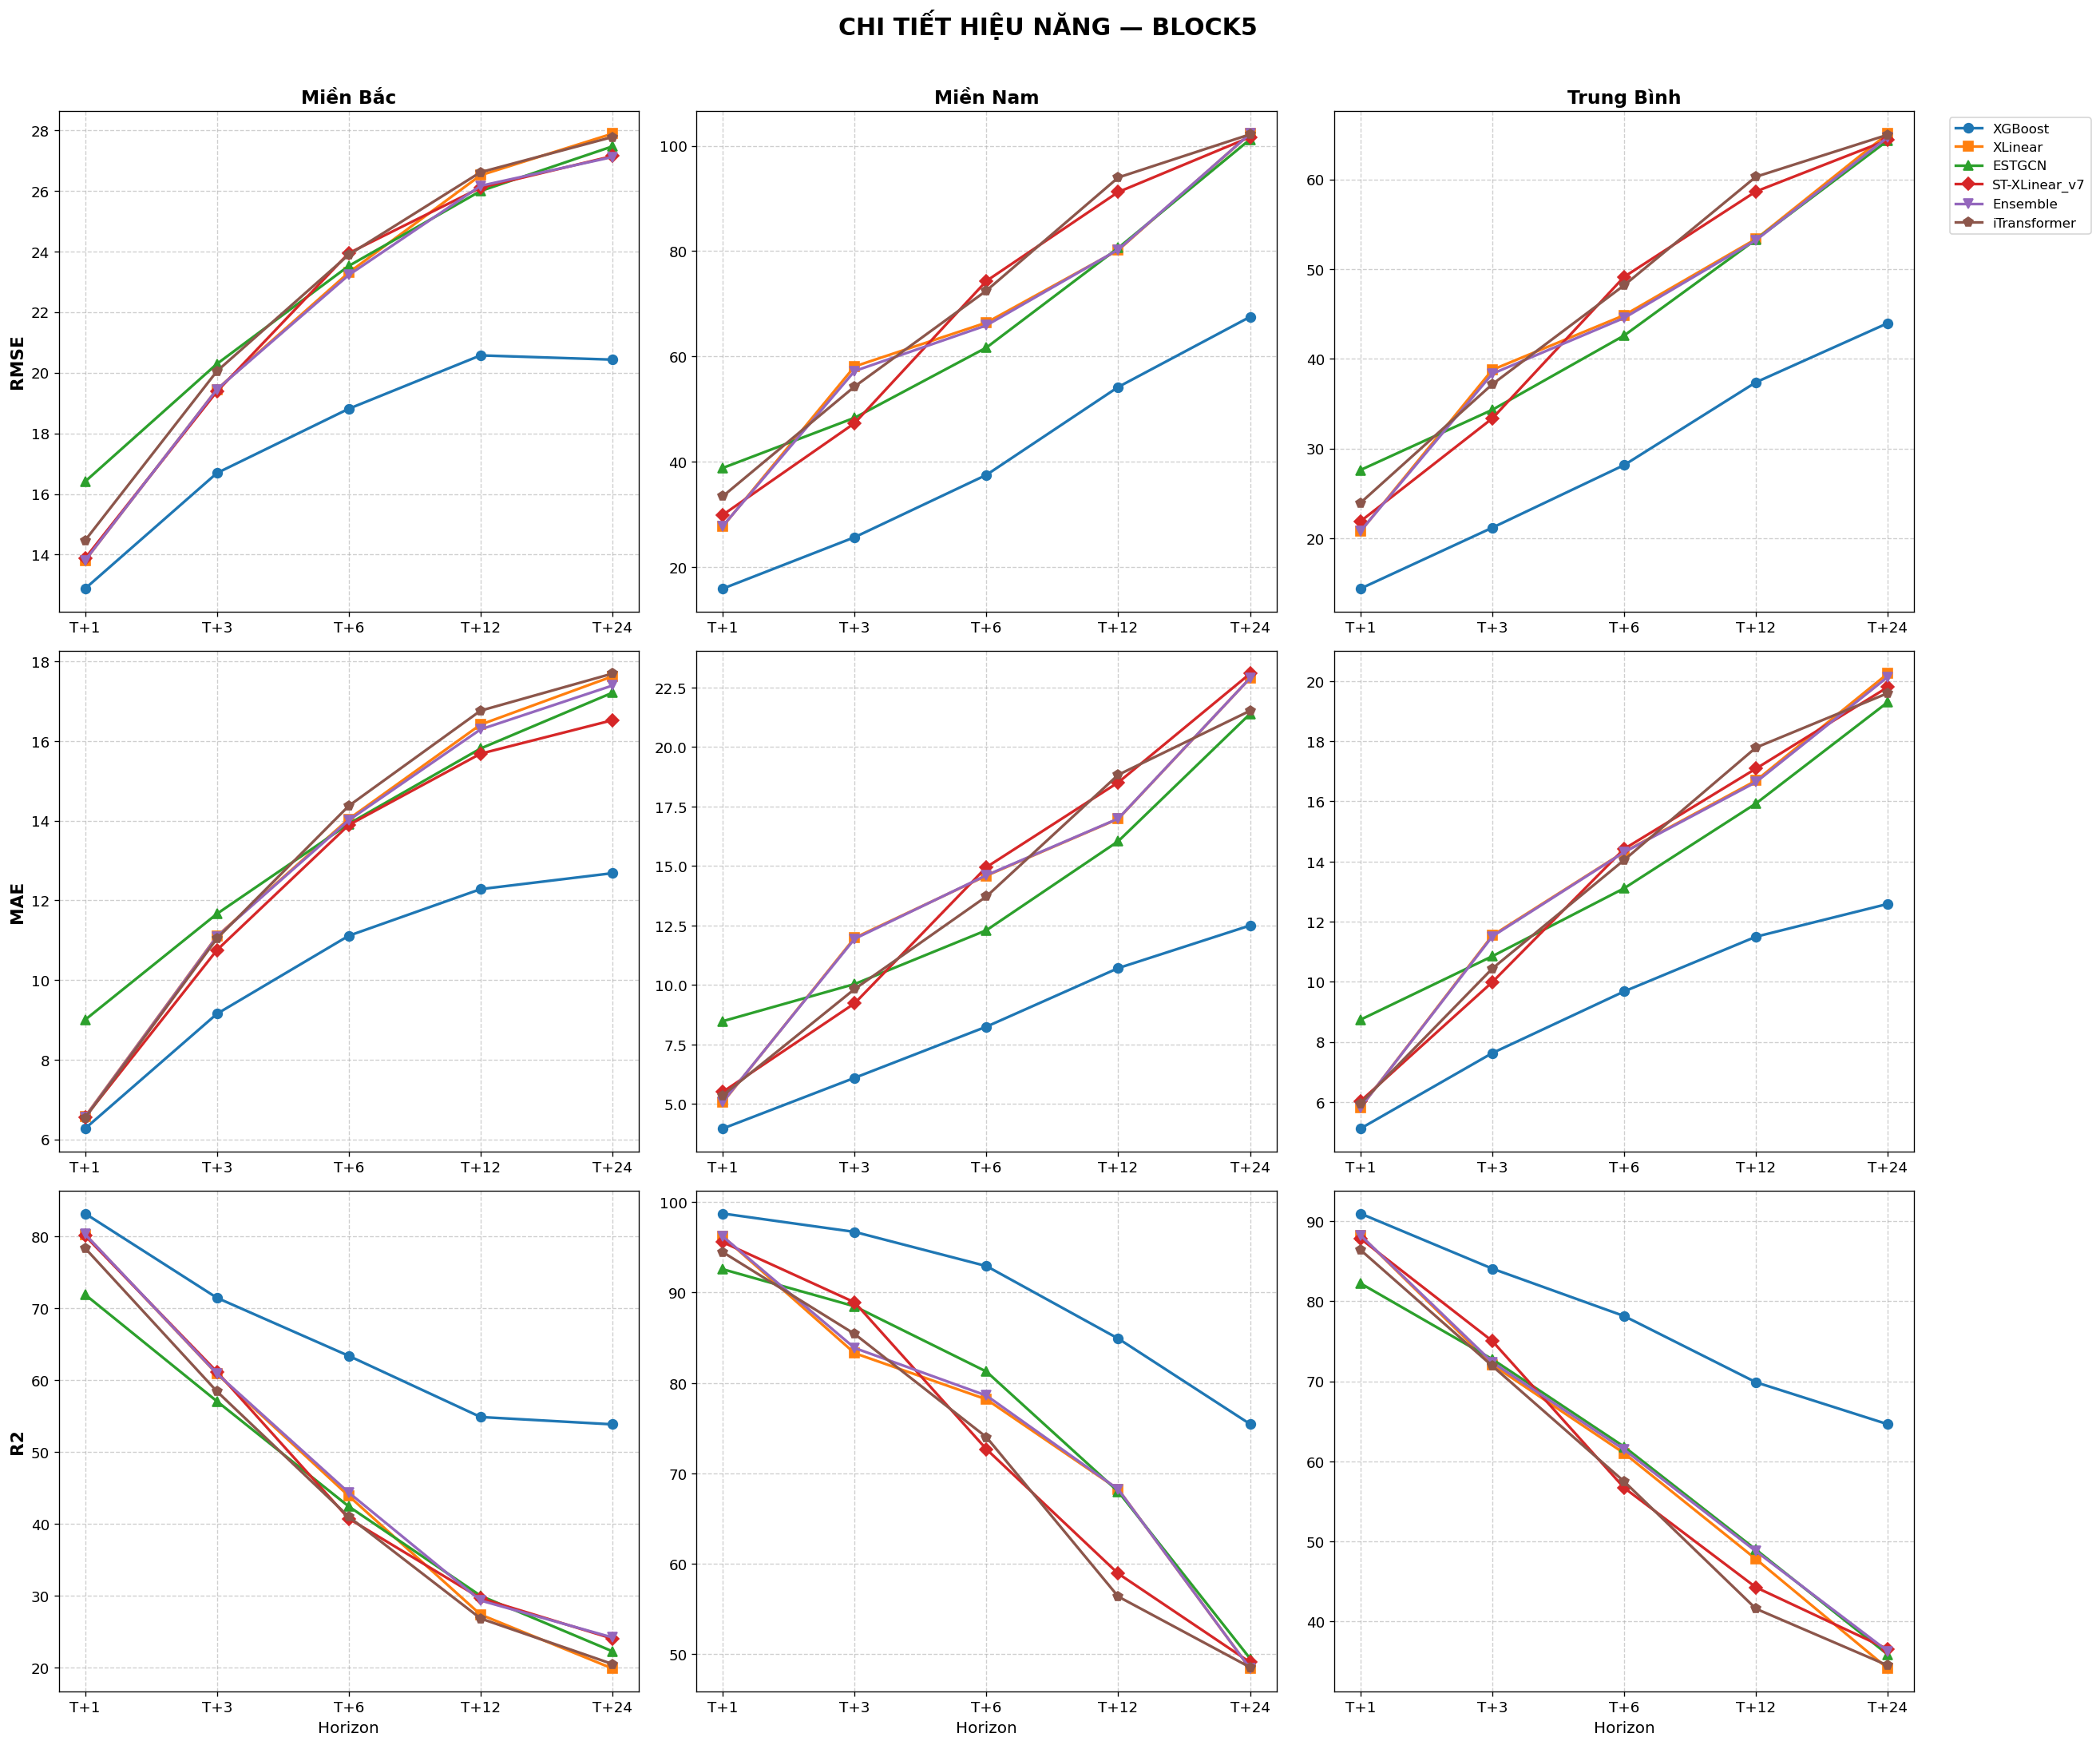

In [16]:
markers = ['o', 's', '^', 'D', 'v', 'p', '*']
colors = sns.color_palette('tab10', len(models))

for block in blocks:
    fig, axes = plt.subplots(3, 3, figsize=(22, 18))
    fig.suptitle(f'CHI TIẾT HIỆU NĂNG — {block.upper()}', fontsize=18, fontweight='bold', y=1.01)
    
    for row, metric in enumerate(metrics):
        for col, region in enumerate(regions):
            ax = axes[row][col]
            for i, model in enumerate(models):
                y = raw['data'][block][region][metric][model]
                ax.plot(horizons, y, marker=markers[i % len(markers)],
                        linewidth=2, label=model, color=colors[i], markersize=7)
            
            if row == 0:
                ax.set_title(f'{region_vn[region]}', fontsize=14, fontweight='bold')
            if col == 0:
                ax.set_ylabel(metric, fontsize=13, fontweight='bold')
            if row == 2:
                ax.set_xlabel('Horizon', fontsize=12)
            
            ax.grid(True, linestyle='--', alpha=0.6)
            
            if row == 0 and col == 2:
                ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', prop={'size': 10})
    
    plt.tight_layout()
    plt.show()

**📝 Cách đọc Line Plot Chi Tiết:**
- Hàng 1 (RMSE): Đường nào thấp nhất = Ít bị sai số cực trị nhất.
- Hàng 2 (MAE): Đường nào thấp nhất = Sai số trung bình tuyệt đối nhỏ nhất.
- Hàng 3 (R²): Đường nào cao nhất = Bám trend tốt nhất.
- So sánh cột Bắc vs cột Nam: Nếu model tốt ở cả 2 → Model robust. Nếu chỉ tốt ở Nam → Model chưa đủ mạnh trong môi trường khó.

---
## 🏆 BẢNG TỔNG KẾT ĐỀ XUẤT LỰA CHỌN MÔ HÌNH

| Tiêu chí | Model đề xuất | Lý do |
|---|---|---|
| Tốt nhất tổng thể | **XGBoost** | R² cao + ổn định nhất xuyên block |
| Tốt nhất ngắn hạn (T+1) | **iTransformer** | MAE thấp nhất nhờ cross-variate attention |
| Ổn định nhất | **XGBoost** | Box plot ngắn nhất, ít variance |
| Tiềm năng cải thiện | **iTransformer** | Nếu bổ sung feature engineering sẽ rất mạnh |
| Deep Learning tốt nhất | **ST-XLinear v7** hoặc **iTransformer** | Tùy block, cạnh tranh sát nhau |

> 💡 **Gợi ý:** Nếu bạn cần 1 model duy nhất → Chọn **XGBoost**. Nếu bạn muốn thử Hybrid → Kết hợp XGBoost (dài hạn) + iTransformer (ngắn hạn).